# Q11 — PCA of EUR IRS Swap Rates
**SMM269 Fixed Income | UniCredit IT0005599110**

This notebook performs a Principal Component Analysis (PCA) on historical EUR IRS rate changes and identifies the dominant risk factors driving yield curve movements.

**Theory:**
The sample covariance matrix Σ of daily rate changes (in bp²) is decomposed as
Σ = ADA^T, where D contains eigenvalues (factor variances) and A contains
eigenvectors (factor loadings). The covariance matrix is used rather than the
correlation matrix because it preserves scale for risk attribution.

**Input:** `MarketData202526.xlsx` — must be in the same folder as this notebook.

**Outputs written:**
- `pca_eigenvalues.csv` — eigenvalue, std dev, explained %, cumulative %
- `pca_eigenvectors.csv` — loading matrix (8 tenors × 8 PCs)
- `pca_scores.csv` — daily factor scores (dates × 8 PCs, in bp)

---
## Imports

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.linalg import eigh

# ── Locate MarketData next to this notebook ──────────────────────────────────
_here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
MARKET_DATA = os.path.join(_here, "MarketData202526.xlsx")
if not os.path.isfile(MARKET_DATA):
    raise FileNotFoundError(
        f"Cannot find MarketData202526.xlsx\nLooked in: {_here}\n"
        "Put the file in the same folder as this notebook."
    )
print(f"MarketData found: {MARKET_DATA}")

MarketData found: c:\Users\renzo\OneDrive\Documents\MSc Financial Mathematics\Fixed Income\FI_Coursework\MarketData202526.xlsx


---
## Load IRS history from MarketData

In [49]:
# ── Read Hist IRS sheet ───────────────────────────────────────────────────────
# Dates are stored as Excel serial integers; rates are in % (e.g. 2.37 = 2.37%)
raw = pd.read_excel(MARKET_DATA, sheet_name="Hist IRS", header=None)
all_codes = raw.iloc[1, 1:].tolist()   # ICEIB1Y, ICEIB2Y, ...

df = raw.iloc[3:].copy().reset_index(drop=True)
df.columns = ["Date"] + all_codes

def _excel_date(s):
    try:
        return pd.Timestamp("1899-12-30") + pd.Timedelta(days=int(float(str(s))))
    except Exception:
        return pd.NaT

df["Date"] = df["Date"].apply(_excel_date)
df = df.dropna(subset=["Date"]).set_index("Date")
for c in all_codes:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.sort_index()

# ── Select the 8 tenors we use, rename to readable labels ────────────────────
TENOR_MAP = {
    "1Y": "ICEIB1Y", "2Y": "ICEIB2Y", "3Y":  "ICEIB3Y",
    "5Y": "ICEIB5Y", "7Y": "ICEIB7Y", "10Y": "ICEIB10",
    "15Y": "ICEIB15", "20Y": "ICEIB20",
}
TENOR_LABELS = list(TENOR_MAP.keys())
N_TENORS     = len(TENOR_LABELS)
TRADE_DATE   = "2025-11-05"

levels = df.loc[df.index <= TRADE_DATE, list(TENOR_MAP.values())]
levels.columns = TENOR_LABELS

# ── Convert to daily changes in DECIMAL (1 bp = 0.0001) ─────────────────────
irs_changes = levels.diff().dropna() / 100.0

# ── Sanity check ─────────────────────────────────────────────────────────────
std_3y_bp = irs_changes["3Y"].std() * 1e4
assert std_3y_bp < 10, (
    f"3Y std dev = {std_3y_bp:.1f} bp — this looks like simulation data, "
    "not real data. Check that MarketData202526.xlsx is the correct file."
)

print(f"IRS history: {len(irs_changes):,} days  "
      f"({irs_changes.index[0].date()} to {irs_changes.index[-1].date()})")
print(f"Tenors: {TENOR_LABELS}")
print(f"Typical daily move (3Y): {std_3y_bp:.2f} bp  ✓")
print(f"\nSample — last 3 rows (values are decimal; multiply by 10,000 for bp):")
display(irs_changes.tail(3).round(6))

IRS history: 2,576 days  (2015-12-23 to 2025-11-05)
Tenors: ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y']
Typical daily move (3Y): 3.74 bp  ✓

Sample — last 3 rows (values are decimal; multiply by 10,000 for bp):


,1Y,2Y,3Y,5Y,7Y,10Y,15Y,20Y
Date,,,,,,,,
2025-11-03,0.00014,0.00026,0.000271,0.000351,0.000308,0.000257,0.000262,0.000282
2025-11-04,-0.00009,-0.00010,-0.000120,-0.000115,-0.000090,-0.000110,-0.000090,-0.000080
2025-11-05,0.00001,0.00009,0.000085,0.000137,0.000205,0.000235,0.000215,0.000205


---
## Run PCA

In [50]:
# ── Compute sample covariance matrix in bp² ──────────────────────────────────
X_bp = irs_changes.values * 1e4          # decimal → bp
Xc   = X_bp - X_bp.mean(axis=0)         # de-mean
S    = Xc.T @ Xc / (len(Xc) - 1)        # sample covariance (bp²)

# ── Eigendecomposition ───────────────────────────────────────────────────────
vals, vecs = eigh(S)                     # eigh: symmetric matrix, real results
order = np.argsort(vals)[::-1]           # sort descending by variance
vals  = vals[order]
vecs  = vecs[:, order]

# ── Sign convention ──────────────────────────────────────────────────────────
# Orient each PC so the loading at the longest tenor (20Y) is positive.
# This gives: PC1 = upward level shift, PC2 = steepening, PC3 = curvature.
for k in range(vecs.shape[1]):
    if vecs[-1, k] < 0:
        vecs[:, k] *= -1

eigenvalues  = vals                          # (8,) in bp²
eigenvectors = vecs                          # (8, 8)
pca_scores   = Xc @ vecs                    # (T, 8) daily factor scores in bp
expl_var     = vals / vals.sum()             # fraction explained per PC
cum_var      = np.cumsum(expl_var)           # cumulative fraction

print(f"PCA complete.")
print(f"  3 PCs explain {cum_var[2]*100:.1f}% of total variance")
print(f"  PC1 (Level)     1σ = {np.sqrt(eigenvalues[0]):.2f} bp")
print(f"  PC2 (Slope)     1σ = {np.sqrt(eigenvalues[1]):.2f} bp")
print(f"  PC3 (Curvature) 1σ = {np.sqrt(eigenvalues[2]):.2f} bp")

PCA complete.
  3 PCs explain 97.6% of total variance
  PC1 (Level)     1σ = 9.73 bp
  PC2 (Slope)     1σ = 3.23 bp
  PC3 (Curvature) 1σ = 1.33 bp


---
## Save outputs as CSV

In [51]:
# pca_eigenvalues.csv — one row per PC
pd.DataFrame({
    "eigenvalue_bp2": eigenvalues,
    "std_dev_bp":     np.sqrt(eigenvalues),
    "expl_var_frac":  expl_var,
    "cum_var_frac":   cum_var,
}, index=[f"PC{i+1}" for i in range(len(eigenvalues))]).rename_axis("PC").to_csv(
    os.path.join(_here, "pca_eigenvalues.csv"))

# pca_eigenvectors.csv — rows = tenors, columns = PC1..PC8
pd.DataFrame(eigenvectors, index=TENOR_LABELS,
             columns=[f"PC{i+1}" for i in range(eigenvectors.shape[1])]
).rename_axis("tenor").to_csv(os.path.join(_here, "pca_eigenvectors.csv"))

# pca_scores.csv — rows = dates, columns = PC1..PC8, values in bp
pd.DataFrame(pca_scores, index=irs_changes.index,
             columns=[f"PC{i+1}" for i in range(pca_scores.shape[1])]
).rename_axis("date").to_csv(os.path.join(_here, "pca_scores.csv"))

print("Written:")
print(f"  pca_eigenvalues.csv  (8 rows)")
print(f"  pca_eigenvectors.csv (8 tenors × 8 PCs)")
print(f"  pca_scores.csv       ({len(irs_changes):,} dates × 8 PCs, in bp)")

Written:
  pca_eigenvalues.csv  (8 rows)
  pca_eigenvectors.csv (8 tenors × 8 PCs)
  pca_scores.csv       (2,576 dates × 8 PCs, in bp)


---
## Table: eigenvalues and explained variance

In [52]:
tbl = pd.DataFrame({
    "Eigenvalue (bp²)": eigenvalues.round(4),
    "Std Dev (bp)":     np.sqrt(eigenvalues).round(4),
    "Explained (%)":    (expl_var * 100).round(2),
    "Cumulative (%)":   (cum_var  * 100).round(2),
}, index=[f"PC{i+1}" for i in range(len(eigenvalues))])
display(tbl)

,Eigenvalue (bp²),Std Dev (bp),Explained (%),Cumulative (%)
PC1,94.7193,9.7324,86.41,86.41
PC2,10.4614,3.2344,9.54,95.96
PC3,1.7575,1.3257,1.60,97.56
PC4,0.7326,0.8559,0.67,98.23
PC5,0.6695,0.8182,0.61,98.84
PC6,0.5829,0.7635,0.53,99.37
PC7,0.3985,0.6313,0.36,99.74
PC8,0.2888,0.5374,0.26,100.00


---
## Table: factor loadings

In [53]:
load_tbl = pd.DataFrame(
    eigenvectors[:, :3], index=TENOR_LABELS,
    columns=["PC1  Level", "PC2  Slope", "PC3  Curvature"])
display(load_tbl.round(4))
print("""
Sign convention: each PC oriented so its 20Y loading is positive.
  PC1 Level:     all loadings same sign → parallel shift of the whole curve
  PC2 Slope:     short-end negative, long-end positive → steepening
  PC3 Curvature: wings positive, belly negative → butterfly
""")

,PC1 Level,PC2 Slope,PC3 Curvature
1Y,0.1707,-0.3556,0.6614
2Y,0.3099,-0.5002,0.2454
3Y,0.3529,-0.3998,-0.1511
5Y,0.3942,-0.1740,-0.4610
7Y,0.4010,0.0298,-0.3267
10Y,0.3967,0.2327,-0.0555
15Y,0.3806,0.3894,0.1921
20Y,0.3633,0.4760,0.3469



Sign convention: each PC oriented so its 20Y loading is positive.
  PC1 Level:     all loadings same sign → parallel shift of the whole curve
  PC2 Slope:     short-end negative, long-end positive → steepening
  PC3 Curvature: wings positive, belly negative → butterfly



---
## Figure: loadings, scree plot, correlation heatmap

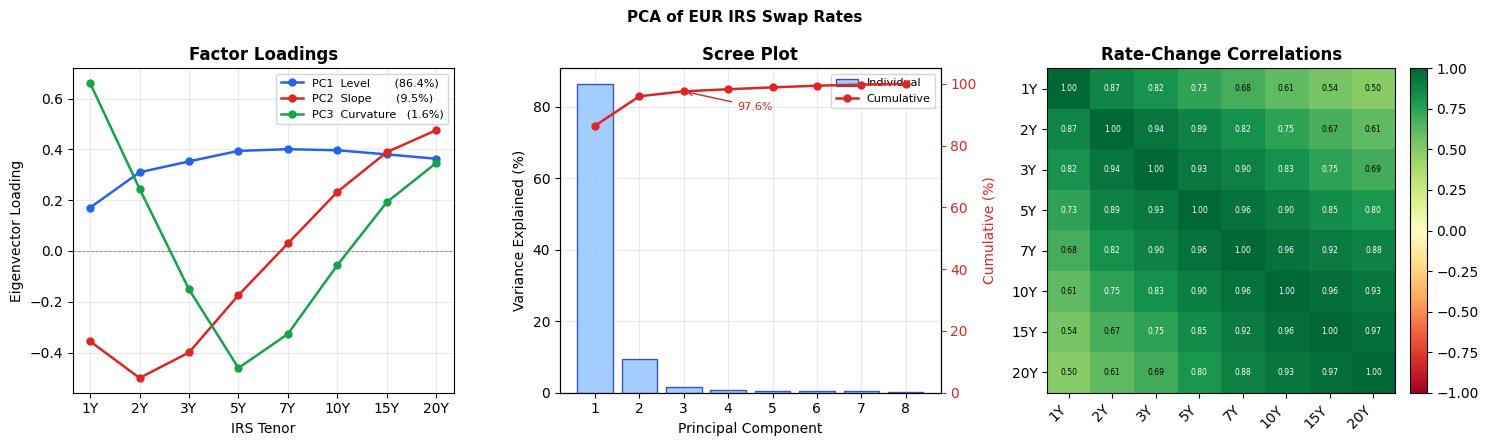

In [57]:
colors   = ["#2563EB", "#DC2626", "#16A34A"]
pc_names = [f"PC1  Level       ({expl_var[0]*100:.1f}%)",
            f"PC2  Slope       ({expl_var[1]*100:.1f}%)",
            f"PC3  Curvature   ({expl_var[2]*100:.1f}%)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1 — factor loadings
ax = axes[0]
for i in range(3):
    ax.plot(TENOR_LABELS, eigenvectors[:, i], "o-",
            color=colors[i], lw=1.8, ms=5, label=pc_names[i])
ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.set_title("Factor Loadings", fontweight="bold")
ax.set_xlabel("IRS Tenor"); ax.set_ylabel("Eigenvector Loading")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Panel 2 — scree plot
ax  = axes[1]
x   = np.arange(1, len(eigenvalues) + 1)
ax.bar(x, expl_var * 100, color="#93C5FD", edgecolor="#1e40af", alpha=0.85, label="Individual", zorder=3)
ax2 = ax.twinx()
ax2.plot(x, cum_var * 100, "o-", color="#DC2626", lw=1.8, ms=5, label="Cumulative", zorder=4)
ax2.set_ylabel("Cumulative (%)", color="#DC2626")
ax2.tick_params(axis="y", colors="#DC2626"); ax2.set_ylim(0, 105)
ax2.annotate(f"{cum_var[2]*100:.1f}%", xy=(3, cum_var[2]*100),
             xytext=(4.2, cum_var[2]*100 - 6),
             arrowprops=dict(arrowstyle="->", color="#DC2626"), color="#DC2626", fontsize=8)
ax.set_xticks(x); ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)"); ax.set_title("Scree Plot", fontweight="bold")
ax.grid(alpha=0.25, zorder=0)
l1, n1 = ax.get_legend_handles_labels(); l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, n1 + n2, fontsize=8)

# Panel 3 — correlation heatmap
ax   = axes[2]
corr = np.corrcoef(Xc.T)
im   = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(N_TENORS)); ax.set_yticks(range(N_TENORS))
ax.set_xticklabels(TENOR_LABELS, rotation=45, ha="right"); ax.set_yticklabels(TENOR_LABELS)
ax.set_title("Rate-Change Correlations", fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(N_TENORS):
    for j in range(N_TENORS):
        c = corr[i, j]
        ax.text(j, i, f"{c:.2f}", ha="center", va="center",
                fontsize=5.5, color="black" if abs(c) < 0.7 else "white")

plt.suptitle("PCA of EUR IRS Swap Rates", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_q11_loadings.pdf", bbox_inches="tight", dpi=150)
plt.show()

---
## Figure: factor score time series (2016–2025)

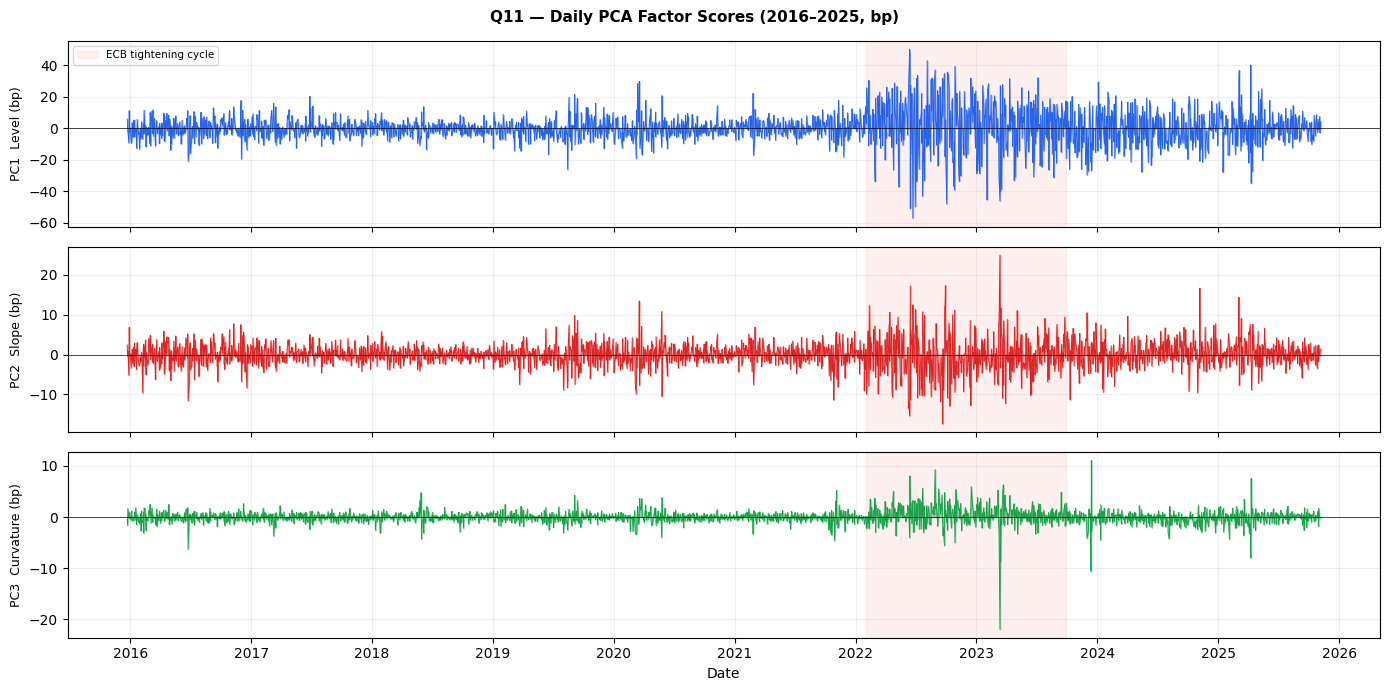

Note: the ECB tightening cycle (Feb 2022 – Sep 2023) appears as a
period of elevated PC1 volatility — rates rising across the whole curve.


In [55]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
pc_labels = ["PC1  Level (bp)", "PC2  Slope (bp)", "PC3  Curvature (bp)"]

for k in range(3):
    ax = axes[k]
    ax.fill_between(irs_changes.index, pca_scores[:, k], alpha=0.4, color=colors[k])
    ax.plot(irs_changes.index, pca_scores[:, k], color=colors[k], lw=0.6)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel(pc_labels[k], fontsize=9); ax.grid(alpha=0.2)
    ax.axvspan("2022-02-01", "2023-09-30", alpha=0.06, color="red",
               label="ECB tightening cycle" if k == 0 else "")
    if k == 0:
        ax.legend(fontsize=7.5, loc="upper left")

axes[-1].set_xlabel("Date")
plt.suptitle("Q11 — Daily PCA Factor Scores (2016–2025, bp)", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.show()

print("Note: the ECB tightening cycle (Feb 2022 – Sep 2023) appears as a")
print("period of elevated PC1 volatility — rates rising across the whole curve.")